# Getting Started with Affon

This notebook demonstrates Affon's compute-first core features: tensors, gradients, neural networks, schedules, and plotting.


In [1]:
import {
  Duration,
  schedules,
  scheduled,
  tensor,
  parameter,
  module,
  add,
  matmul,
  randn,
  mul,
  sum,
  sigmoid,
  clear_grad,
  grad,
  sgd,
} from 'affon:compute'
import type { Tensor } from 'affon:compute'
import nn from 'affon:nn'
import { figure, title, xlabel, ylabel, plot, scatter, show } from 'affon:plot'


## 1. Compute Tensors


In [2]:
const a = tensor([[1, 2, 3], [4, 5, 6]])
console.log('shape:', a.shape)
console.log('dtype:', a.dtype)
console.log(a)


shape: [ 2, 3 ]
dtype: f32
[2×3 Tensor, dtype=f32]
     0  1  2
  ┌           ┐
0 │  1  2  3  │
1 │  4  5  6  │
  └           ┘



In [3]:
const x = tensor([[1, 2], [3, 4]])
const y = tensor([[10, 20], [30, 40]])
console.log('add:', add(x, y).to_array())
console.log('matmul:', matmul(x, y).to_array())


add: [ [ 11, 22 ], [ 33, 44 ] ]
matmul: [ [ 70, 100 ], [ 150, 220 ] ]


## 2. Autograd

In [4]:
const a = parameter([2]).randn()
const b = tensor([4, 5])
const c = sum(mul(a, b))
console.log('c =', c)

grad(c, [a])
console.log('dc/da =', a.grad)


c = [1 Tensor, dtype=f32]
  0         
[ 1.025905  ]

dc/da = [2 Tensor, dtype=f32]
  0  1  
[ 4  5  ]



## 3. Neural Network: Linear Regression

In [5]:
// y = 2x + 1
const X = tensor([[1], [2], [3], [4], [5]])
const Y = tensor([[3], [5], [7], [9], [11]])

const W = parameter([1, 1]).randn()
const b = parameter([1, 1]).randn()
const params = [W, b]
const step = sgd({ lr: 0.01 })
const criterion = nn.MSELoss()

for (let i = 0; i < 200; i++) {
  clear_grad(params)
  const pred = add(matmul(X, W), b)
  const loss = criterion(pred, Y)
  grad(loss, params)
  step(params)
  if (i % 50 === 0) console.log(`epoch ${i}: loss =`, loss)
}

console.log('W:', W, 'b:', b)


epoch 0: loss = [1 Tensor, dtype=f32]
  0          
[ 15.016531  ]

epoch 50: loss = [1 Tensor, dtype=f32]
  0         
[ 0.275305  ]

epoch 100: loss = [1 Tensor, dtype=f32]
  0         
[ 0.196215  ]

epoch 150: loss = [1 Tensor, dtype=f32]
  0         
[ 0.139846  ]

W: [1×1 Tensor, dtype=f32]
            0
  ┌            ┐
0 │  2.204966  │
  └            ┘
 b: [1×1 Tensor, dtype=f32]
            0
  ┌            ┐
0 │  0.260008  │
  └            ┘



## 4. Plotting

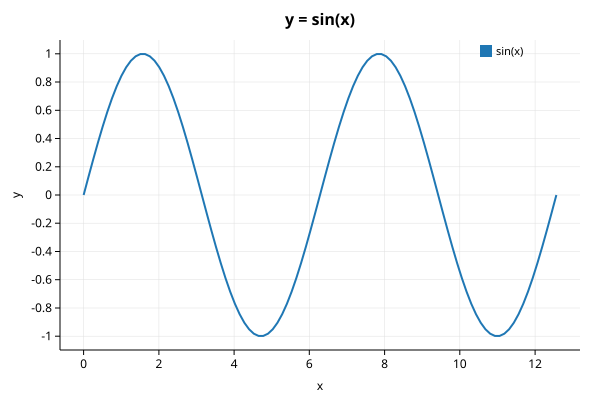

In [6]:

figure({ width: 600, height: 400 })
title('y = sin(x)')
xlabel('x')
ylabel('y')

const xs: number[] = []
const ys: number[] = []
for (let i = 0; i <= 100; i++) {
  const x = (i / 100) * 4 * Math.PI
  xs.push(x)
  ys.push(Math.sin(x))
}
plot(xs, ys, { label: 'sin(x)', color: '#1f77b4' })
show()

## 5. Custom Module: Logistic Regression (Factory Style)

In [7]:
const LogisticRegression = (in_features: number, out_features: number) => {
  const W = parameter([in_features, out_features]).randn()
  const b = parameter([1, out_features]).randn()

  return module({ W, b }, (state, X: Tensor): Tensor => {
    return add(matmul(X, state.W), state.b)
  })
}

const X = tensor([[1], [5], [10], [10], [25], [50], [70], [75], [100]])
const Y = tensor([[0], [0], [0], [0], [0], [1], [1], [1], [1]])

const model = LogisticRegression(1, 1)
const params = model.parameters
const step = sgd({ lr: 0.004 })
const criterion = nn.BCEWithLogitsLoss()

for (let epoch = 0; epoch < 2000; epoch++) {
  clear_grad(params)
  const logits = model(X)
  const loss = criterion(logits, Y)
  grad(loss, params)
  step(params)

  if (epoch % 200 === 0) {
    console.log('epoch', epoch, 'loss =', loss.item())
  }
}

const probs = sigmoid(model(X))
console.log('probabilities:', probs)


epoch 0 loss = 7.113641738891602
epoch 200 loss = 0.8061520457267761
epoch 400 loss = 0.7156469821929932
epoch 600 loss = 0.637317419052124
epoch 800 loss = 0.5700812339782715
epoch 1000 loss = 0.5126478672027588
epoch 1200 loss = 0.46367624402046204
epoch 1400 loss = 0.42188894748687744
epoch 1600 loss = 0.38613617420196533
epoch 1800 loss = 0.35542210936546326
probabilities: [9×1 Tensor, dtype=f32]
            0
  ┌            ┐
0 │  0.293249  │
1 │  0.333304  │
2 │  0.386914  │
3 │  0.386914  │
4 │  0.559375  │
5 │  0.802739  │
6 │  0.911767  │
7 │  0.928799  │
8 │  0.976644  │
  └            ┘



## Scheduled Optimizer

Learning-rate schedules are part of `affon:compute`. They track `{ epoch, step }` during training through `scheduled(...)`.


In [8]:
const scheduledModel = LogisticRegression(1, 1)
const baseStep = sgd({ lr: 0.004 })
const schedule = schedules.sequence(
  schedules.linear({
    start: 0,
    end: 0.004,
    duration: Duration.steps(100),
  }),
  schedules.cosine({
    start: 0.004,
    end: 0.0005,
    duration: Duration.steps(900),
  }),
  schedules.constant(0.0005)
)
const scheduledStep = scheduled(baseStep, schedule)
const scheduledParams = scheduledModel.parameters

for (let epoch = 0; epoch < 10; epoch++) {
  scheduledStep.epoch(epoch)

  for (let stepIndex = 0; stepIndex < 100; stepIndex++) {
    clear_grad(scheduledParams)
    const logits = scheduledModel(X)
    const loss = criterion(logits, Y)
    grad(loss, scheduledParams)
    scheduledStep(scheduledParams)
  }

  if (epoch % 2 === 0) {
    console.log('epoch', epoch, 'lr =', scheduledStep.lr, 'step =', scheduledStep.context.step)
  }
}

console.log('Final scheduled W:', scheduledModel.state().W, 'b:', scheduledModel.state().b)


epoch 0 lr = 0.00396 step = 100
epoch 2 lr = 0.003594496166288666 step = 300
epoch 4 lr = 0.002559898295559271 step = 500
epoch 6 lr = 0.0013802955682017783 step = 700
epoch 8 lr = 0.0006076372101707771 step = 900
Final scheduled W: [1×1 Tensor, dtype=f32]
            0
  ┌            ┐
0 │  0.079191  │
  └            ┘
 b: [1×1 Tensor, dtype=f32]
             0
  ┌             ┐
0 │  -2.393223  │
  └             ┘



## Save And Load A Model

Modules can save their current parameter state to SafeTensors and load it back into a fresh instance with the same architecture.


In [9]:
const savePath = '/tmp/affon-logreg.safetensors'
model.save(savePath)

const restored = LogisticRegression(1, 1)
restored.load(savePath)

const originalProb = sigmoid(model(X)).to_array()
const restoredProb = sigmoid(restored(X)).to_array()

console.log('original probabilities:', originalProb)
console.log('restored probabilities:', restoredProb)


original probabilities: [ [ 0.2932486832141876 ], [ 0.33330437541007996 ], [ 0.3869141936302185 ], [ 0.3869141936302185 ], [ 0.5593746900558472 ], [ 0.8027390837669373 ], [ 0.9117670655250549 ], [ 0.9287986159324646 ], [ 0.9766437411308289 ] ]
restored probabilities: [ [ 0.2932486832141876 ], [ 0.33330437541007996 ], [ 0.3869141936302185 ], [ 0.3869141936302185 ], [ 0.5593746900558472 ], [ 0.8027390837669373 ], [ 0.9117670655250549 ], [ 0.9287986159324646 ], [ 0.9766437411308289 ] ]


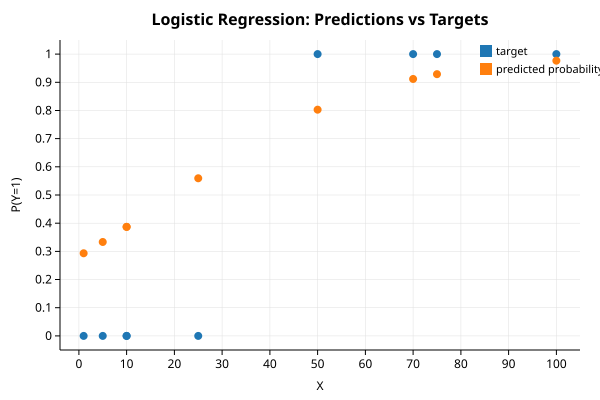

In [10]:
figure({ width: 600, height: 400 })
title('Logistic Regression: Predictions vs Targets')
xlabel('X')
ylabel('P(Y=1)')
scatter(X, Y, { color: '#1f77b4', label: 'target' })
scatter(X, sigmoid(model(X)), { color: '#ff7f0e', label: 'predicted probability' })
show()
